In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.fft import fft, fftfreq
# ============================================================
# MODÈLE MULTI-ÉCHELLES — VERSION CORRIGÉE
# ============================================================
#

#

K = 10
ell_min = 1
ell_max = 48

ells = ell_min * (ell_max / ell_min) ** (np.linspace(0, 1, K))
print(ells)
alphas_multi = 1 / (1 + ells)
print(alphas_multi)
# ============================================================

def simulate_chiarella(NIT, kappa, kappa_3, beta_total, gamma, lst_alpha,
                       sigmaN, sigmaV, P0, V0, g=0.0011):
    """
    Simule le modèle de Chiarella multi-échelles.
    Si len(lst_alpha) == 1, se comporte comme le modèle classique mono-échelle.
    """
    P = np.zeros(NIT)
    V = np.zeros(NIT)
    alphas = np.array(lst_alpha)
    K = len(alphas)
    M = np.zeros((K, NIT))




    if K>1:
        raw = 1.0 / ells**1.15
        beta =  beta_total * raw / raw.sum()
    else:
        beta = np.ones(K) * beta_total / K   # betas égaux au départ

    epsilons = np.random.normal(0, sigmaN, NIT)
    etas     = np.random.normal(0, sigmaV, NIT)

    P[0] = P0; P[1] = P0
    V[0] = V0; V[1] = V0 + g

    for t in range(1, NIT - 1):
        # 1. Demande chartiste agrégée
        signals = np.tanh(gamma * M[:, t])
        chartist_demand = np.dot(beta, signals)

        # 2. Mise à jour du Prix
        P[t+1] = (P[t]
                  + kappa * (V[t] - P[t])
                  + chartist_demand
                  + kappa_3 * (V[t] - P[t])**3
                  + epsilons[t+1])

        # 3. Mise à jour de la Valeur Fondamentale
        V[t+1] = V[t] + g + etas[t+1]


    

        # 5. Mise à jour des signaux de momentum pour t+1
        for i in range(K):
            M[i, t+1] = (1 - alphas[i]) * M[i, t] + alphas[i] * (P[t] - P[t-1])

    return P, V


def get_bubble_stats(P, V):
    delta = P - V
    signs = np.sign(delta); signs[signs == 0] = 1
    crossings = np.where(np.diff(signs) != 0)[0]
    if len(crossings) == 0:
        return np.array([len(P)]), np.array([np.max(np.abs(delta))]), delta
    
    boundaries = np.concatenate([[0], crossings, [len(delta)]])
    durations, amplitudes = [], []
    for k in range(len(boundaries) - 1):
        segment = delta[boundaries[k]:boundaries[k+1]]
        if len(segment) == 0:  # ← garde anti-segment vide
            continue
        durations.append(len(segment))
        amplitudes.append(np.max(np.abs(segment)))
    
    return np.array(durations), np.array(amplitudes), delta


# Calibration JP
params = dict(
    NIT=500,
    kappa= -0.011,
    kappa_3=0.269,
    beta_total=0.018, 
    gamma=25,
    sigmaN=0.057, 
    sigmaV=0.018,
    P0=7.94, V0=7.94, g=0.0024
)






[ 1.          1.53746268  2.36379148  3.63424119  5.58751018  8.59058837
 13.207709   20.30635964 31.22027006 48.        ]
[0.5        0.39409447 0.29728359 0.21578506 0.15180242 0.10426889
 0.07038432 0.04693434 0.03103636 0.02040816]


Statistique                          Mono      Multi
Std(mispricing)                    0.2121     0.1985
Max|mispricing|                    0.6471     0.6316
Durée moy. bulles                    20.0       16.1
Durée max bulles                      111        111
Kurtosis des returns                 3.03       2.82


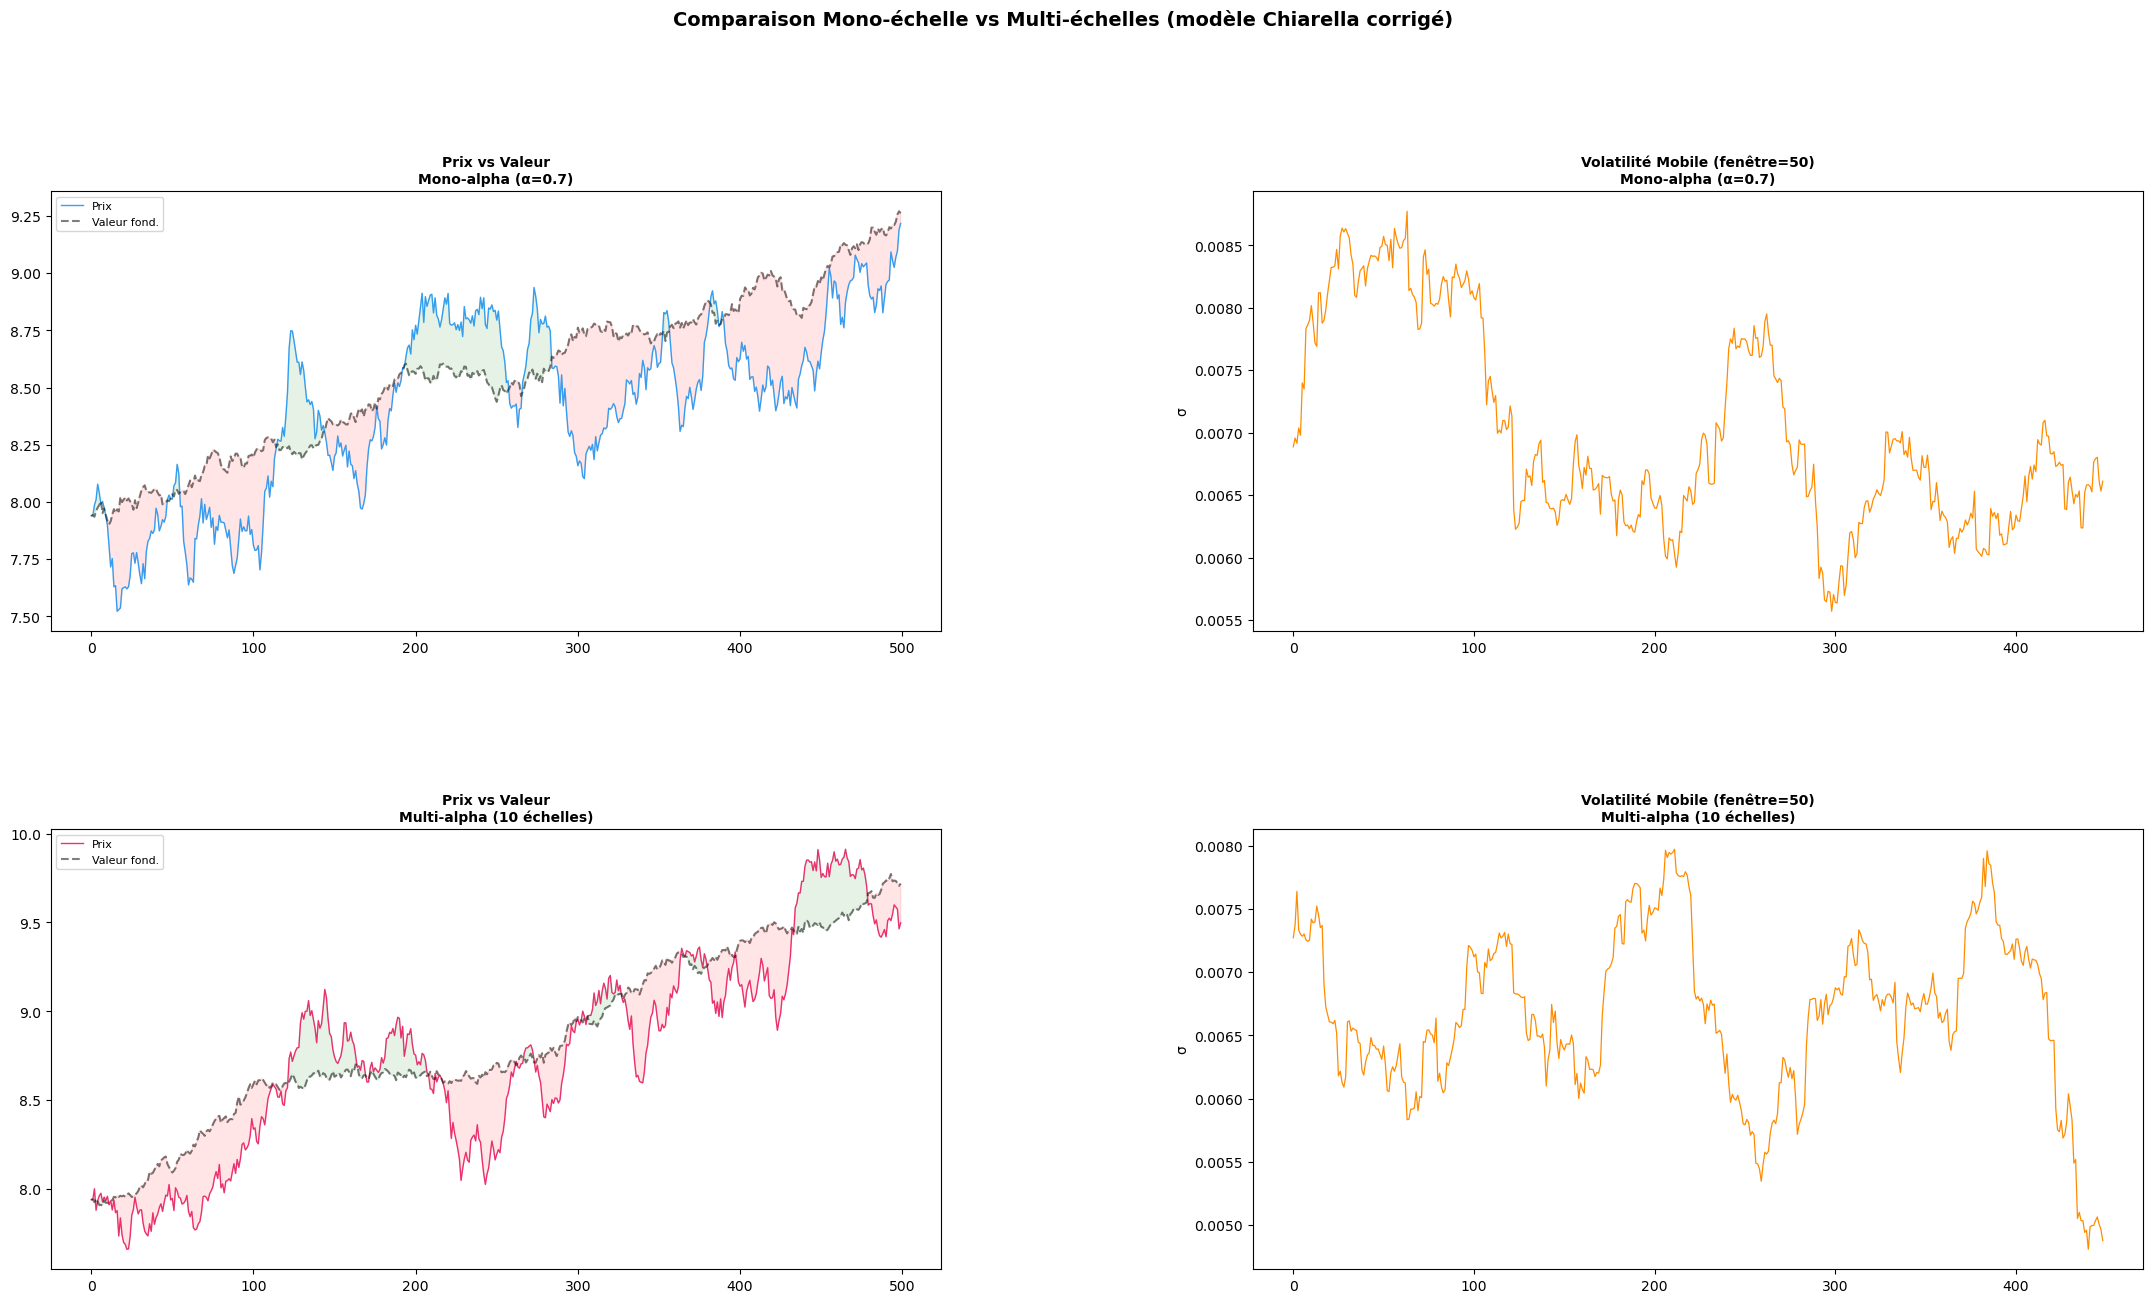

In [10]:
# ============================================================
# SIMULATION COMPARATIVE : Mono vs Multi
# ============================================================
#np.random.seed(1)

P_m, V_m = simulate_chiarella(**params, lst_alpha=alphas_multi)
#P_m, V_m = simulate_chiarella(**params, lst_alpha=[0.7])
P_s, V_s = simulate_chiarella(**params, lst_alpha=[0.7])

durations_m, delta_m, amplitudes_m = get_bubble_stats(P_m, V_m)
durations_s, delta_s, amplitudes_s = get_bubble_stats(P_s, V_s)

returns_m = np.diff(np.log(np.clip(P_m, 1e-6, None)))
returns_s = np.diff(np.log(np.clip(P_s, 1e-6, None)))

print("=" * 55)
print(f"{'Statistique':<30} {'Mono':>10} {'Multi':>10}")
print("=" * 55)
print(f"{'Std(mispricing)':<30} {np.std(delta_s):>10.4f} {np.std(delta_m):>10.4f}")
print(f"{'Max|mispricing|':<30} {np.max(np.abs(delta_s)):>10.4f} {np.max(np.abs(delta_m)):>10.4f}")
print(f"{'Durée moy. bulles':<30} {np.mean(durations_s):>10.1f} {np.mean(durations_m):>10.1f}")
print(f"{'Durée max bulles':<30} {np.max(durations_s):>10.0f} {np.max(durations_m):>10.0f}")
print(f"{'Kurtosis des returns':<30} {stats.kurtosis(returns_s, fisher=False):>10.2f} {stats.kurtosis(returns_m, fisher=False):>10.2f}")
print("=" * 55)

# ============================================================
# GRAPHIQUES COMPARATIFS COMPLETS
# ============================================================
from statsmodels.tsa.stattools import acf

fig = plt.figure(figsize=(27, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

labels = ["Mono-alpha (α=0.7)", "Multi-alpha (10 échelles)"]
colors_model = ["#2196F3", "#E91E63"]

for idx, (P, V, label, col) in enumerate(
        [(P_s, V_s, labels[0], colors_model[0]),
         (P_m, V_m, labels[1], colors_model[1])]):

    durations, delta, amplitudes = get_bubble_stats(P, V)
    returns = np.diff(np.log(np.clip(P, 1e-6, None)))
    window = 50
    volatility = [np.std(returns[i:i+window]) for i in range(len(returns)-window)]

    row = idx

    # --- Col 0 : Prix vs Valeur ---
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(P, lw=1, color=col, label="Prix", alpha=0.9)
    ax.plot(V, lw=1.5, ls="--", color="black", alpha=0.5, label="Valeur fond.")
    ax.set_title(f"Prix vs Valeur\n{label}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.fill_between(range(len(P)), P, V, where=(P > V), alpha=0.1, color='green')
    ax.fill_between(range(len(P)), P, V, where=(P < V), alpha=0.1, color='red')

    # --- Col 1 : Volatilité mobile ---
    ax = fig.add_subplot(gs[row, 1])
    ax.plot(volatility, color="darkorange", lw=0.9)
    ax.set_title(f"Volatilité Mobile (fenêtre={window})\n{label}", fontsize=10, fontweight='bold')
    ax.set_ylabel("σ")

    # --- Col 2 : Distribution des returns (queues épaisses) ---



plt.suptitle("Comparaison Mono-échelle vs Multi-échelles (modèle Chiarella corrigé)",
             fontsize=14, fontweight='bold', y=1.01)
plt.show()


Statistique                          Mono      Multi
Std(mispricing)                    0.1974     0.2067
Max|mispricing|                    0.6583     0.6410
Durée moy. bulles                    19.2       16.7
Durée max bulles                       83        130
Kurtosis des returns                 3.22       2.69


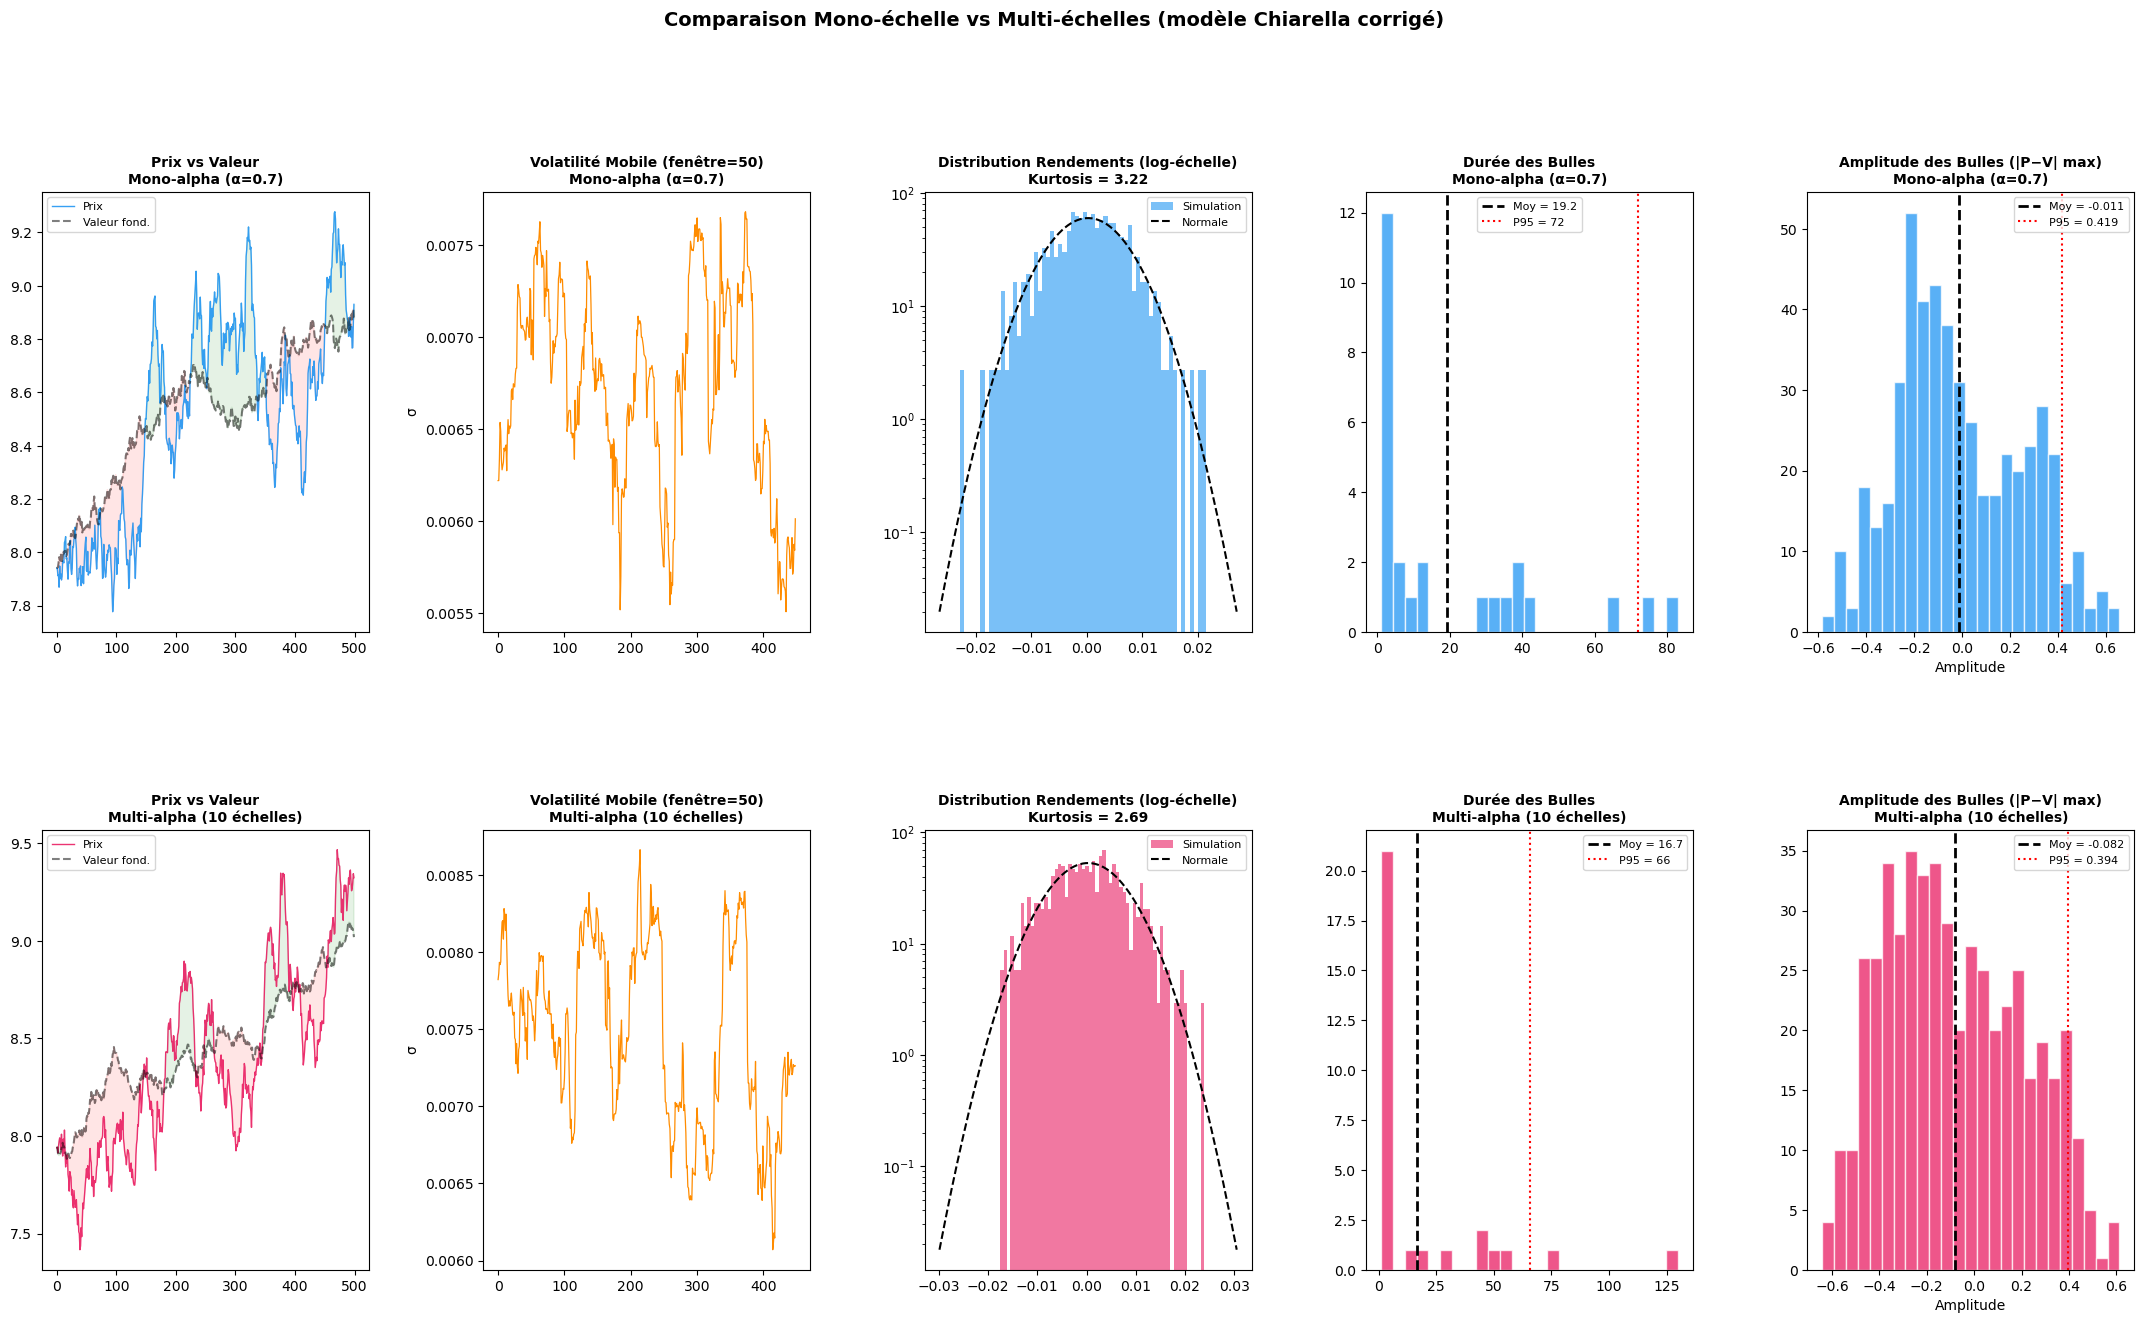

In [11]:
# ============================================================
# SIMULATION COMPARATIVE : Mono vs Multi
# ============================================================
#np.random.seed(1)

P_m, V_m = simulate_chiarella(**params, lst_alpha=alphas_multi)
#P_m, V_m = simulate_chiarella(**params, lst_alpha=[0.7])
P_s, V_s = simulate_chiarella(**params, lst_alpha=[0.7])

durations_m, delta_m, amplitudes_m = get_bubble_stats(P_m, V_m)
durations_s, delta_s, amplitudes_s = get_bubble_stats(P_s, V_s)

returns_m = np.diff(np.log(np.clip(P_m, 1e-6, None)))
returns_s = np.diff(np.log(np.clip(P_s, 1e-6, None)))

print("=" * 55)
print(f"{'Statistique':<30} {'Mono':>10} {'Multi':>10}")
print("=" * 55)
print(f"{'Std(mispricing)':<30} {np.std(delta_s):>10.4f} {np.std(delta_m):>10.4f}")
print(f"{'Max|mispricing|':<30} {np.max(np.abs(delta_s)):>10.4f} {np.max(np.abs(delta_m)):>10.4f}")
print(f"{'Durée moy. bulles':<30} {np.mean(durations_s):>10.1f} {np.mean(durations_m):>10.1f}")
print(f"{'Durée max bulles':<30} {np.max(durations_s):>10.0f} {np.max(durations_m):>10.0f}")
print(f"{'Kurtosis des returns':<30} {stats.kurtosis(returns_s, fisher=False):>10.2f} {stats.kurtosis(returns_m, fisher=False):>10.2f}")
print("=" * 55)

# ============================================================
# GRAPHIQUES COMPARATIFS COMPLETS
# ============================================================
from statsmodels.tsa.stattools import acf

fig = plt.figure(figsize=(27, 14))
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)

labels = ["Mono-alpha (α=0.7)", "Multi-alpha (10 échelles)"]
colors_model = ["#2196F3", "#E91E63"]

for idx, (P, V, label, col) in enumerate(
        [(P_s, V_s, labels[0], colors_model[0]),
         (P_m, V_m, labels[1], colors_model[1])]):

    durations, delta, amplitudes = get_bubble_stats(P, V)
    returns = np.diff(np.log(np.clip(P, 1e-6, None)))
    window = 50
    volatility = [np.std(returns[i:i+window]) for i in range(len(returns)-window)]

    row = idx

    # --- Col 0 : Prix vs Valeur ---
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(P, lw=1, color=col, label="Prix", alpha=0.9)
    ax.plot(V, lw=1.5, ls="--", color="black", alpha=0.5, label="Valeur fond.")
    ax.set_title(f"Prix vs Valeur\n{label}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.fill_between(range(len(P)), P, V, where=(P > V), alpha=0.1, color='green')
    ax.fill_between(range(len(P)), P, V, where=(P < V), alpha=0.1, color='red')

    # --- Col 1 : Volatilité mobile ---
    ax = fig.add_subplot(gs[row, 1])
    ax.plot(volatility, color="darkorange", lw=0.9)
    ax.set_title(f"Volatilité Mobile (fenêtre={window})\n{label}", fontsize=10, fontweight='bold')
    ax.set_ylabel("σ")

    # --- Col 2 : Distribution des returns (queues épaisses) ---
    ax = fig.add_subplot(gs[row, 2])
    ax.hist(returns, bins=60, density=True, alpha=0.6, color=col, label="Simulation")
    mu, sigma = np.mean(returns), np.std(returns)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', lw=1.5, label="Normale")
    ax.set_yscale('log')
    ax.set_title(f"Distribution Rendements (log-échelle)\nKurtosis = {stats.kurtosis(returns, fisher=False):.2f}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # --- Col 3 : Distribution durées des bulles ---
    ax = fig.add_subplot(gs[row, 3])
    ax.hist(durations, bins=25, color=col, edgecolor='white', alpha=0.75)
    ax.axvline(np.mean(durations), color='black', lw=2, ls='--',
               label=f"Moy = {np.mean(durations):.1f}")
    ax.axvline(np.percentile(durations, 95), color='red', lw=1.5, ls=':',
               label=f"P95 = {np.percentile(durations, 95):.0f}")
    ax.set_title(f"Durée des Bulles\n{label}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[row, 4])
    ax.hist(amplitudes, bins=25, color=col, edgecolor='white', alpha=0.75)
    ax.axvline(np.mean(amplitudes), color='black', lw=2, ls='--',
               label=f"Moy = {np.mean(amplitudes):.3f}")
    ax.axvline(np.percentile(amplitudes, 95), color='red', lw=1.5, ls=':',
               label=f"P95 = {np.percentile(amplitudes, 95):.3f}")
    ax.set_title(f"Amplitude des Bulles (|P−V| max)\n{label}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Amplitude")
    ax.legend(fontsize=8)

plt.suptitle("Comparaison Mono-échelle vs Multi-échelles (modèle Chiarella corrigé)",
             fontsize=14, fontweight='bold', y=1.01)
plt.show()


In [ ]:
# ============================================================
# VALIDATION MONTE CARLO : différences statistiquement robustes
# ============================================================
N = 100
results = {
    'dur_m': np.zeros(N), 'dur_s': np.zeros(N),
    'std_m': np.zeros(N), 'std_s': np.zeros(N),
    'dur95_m': np.zeros(N), 'dur95_s': np.zeros(N),
    'amp_m': np.zeros(N), 'amp_s': np.zeros(N),       # amplitude moyenne
    'amp95_m': np.zeros(N), 'amp95_s': np.zeros(N),   # amplitude P95
}

for i in range(N):
    P_s, V_s = simulate_chiarella(**params, lst_alpha=[0.7])
    P_m, V_m = simulate_chiarella(**params, lst_alpha=alphas_multi)
    d_m, amplitudes_m, delta_m = get_bubble_stats(P_m, V_m)
    d_s, amplitudes_s, delta_s = get_bubble_stats(P_s, V_s)

    results['dur_m'][i] = np.mean(d_m);        results['dur_s'][i] = np.mean(d_s)
    results['std_m'][i] = np.std(delta_m);     results['std_s'][i] = np.std(delta_s)
    results['dur95_m'][i] = np.percentile(d_m, 95)
    results['dur95_s'][i] = np.percentile(d_s, 95)
    results['amp_m'][i] = np.mean(amplitudes_m)
    results['amp_s'][i] = np.mean(amplitudes_s)
    results['amp95_m'][i] = np.percentile(amplitudes_m, 95)
    results['amp95_s'][i] = np.percentile(amplitudes_s, 95)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

metrics = [
    ('dur_s',   'dur_m',   'Durée moy. bulles'),
    ('std_s',   'std_m',   'Std(Mispricing)'),
    ('dur95_s', 'dur95_m', 'Durée P95 bulles'),
    ('amp_s',   'amp_m',   'Amplitude moy. bulles'),
    ('amp95_s', 'amp95_m', 'Amplitude P95 bulles'),
]

for ax, (key_s, key_m, title) in zip(axes, metrics):
    ax.hist(results[key_s], bins=30, alpha=0.6, color='#2196F3',
            label=f"Mono  (moy={np.mean(results[key_s]):.3f})")
    ax.hist(results[key_m], bins=30, alpha=0.6, color='#E91E63',
            label=f"Multi (moy={np.mean(results[key_m]):.3f})")
    t_stat, p_val = stats.ttest_ind(results[key_m], results[key_s])
    ax.set_title(f"{title}\np-value = {p_val:.4f} "
                 f"({'✓ Signif.' if p_val < 0.05 else '✗ Non-signif.'})")
    ax.legend(fontsize=9)
    ax.set_xlabel("Valeur")

plt.suptitle(f"Distribution sur {N} simulations Monte Carlo", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRésumé des différences moyennes (Multi vs Mono) :")
for key_s, key_m, title in metrics:
    diff_pct = 100 * (np.mean(results[key_m]) - np.mean(results[key_s])) / np.mean(results[key_s])
    t, p = stats.ttest_ind(results[key_m], results[key_s])
    sign = "✓" if p < 0.05 else "✗"
    print(f"  {sign} {title:<28}: {diff_pct:+.1f}%  (p={p:.4f})")